In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import netCDF4 as nc
from scipy.stats import linregress

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import phys_grad, compute_core_mean


In [2]:
df_ameda = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_ameda_renamed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_tilt_ameda.pkl')
df_ameda = df_ameda.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
df_AE = df_ameda[df_ameda.Cyc=='AE'].copy()
df_CE = df_ameda[df_ameda.Cyc=='CE'].copy()
df_ameda


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,split2,merge,merge2,shapes2,interaction,interaction2,area,deta,TiltDis,TiltDir
0,1,1462,AE,159.538447,-33.372496,256,186,895.838095,919.548973,0.000010,...,NaN,NaN,NaN,NaN,NaN,NaN,46653.514371,-0.000011,NaN,NaN
1,1,1463,AE,159.686966,-33.160751,257,192,903.002279,946.853133,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,4313.383226,-0.000164,NaN,NaN
2,1,1464,AE,159.649836,-33.118402,256,192,898.424872,950.150915,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,4336.799061,-0.000070,NaN,NaN
3,1,1465,AE,159.686966,-33.118402,257,193,901.765461,951.353349,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,6480.379311,-0.000047,16.147158,80.585819
4,1,1466,AE,159.575577,-32.949006,254,196,886.770848,965.738198,0.000020,...,NaN,NaN,NaN,NaN,NaN,NaN,6101.676103,-0.000401,19.455358,63.680275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104565,3519,10643,CE,154.897235,-28.841152,125,252,327.112431,1244.142958,-0.000014,...,NaN,NaN,NaN,NaN,NaN,NaN,1147.953129,0.000186,8.196140,194.802223
104566,3519,10647,CE,154.860106,-29.052897,127,247,331.141370,1220.843200,-0.000011,...,NaN,NaN,NaN,NaN,NaN,NaN,8038.013328,0.000109,43.813072,358.254256
104567,3519,10648,CE,154.897235,-29.222293,130,244,340.502393,1204.416117,-0.000011,...,NaN,NaN,NaN,NaN,NaN,NaN,9866.414298,0.000095,NaN,NaN
104568,3519,10649,CE,154.377420,-28.417662,100,257,264.105244,1270.945276,-0.000010,...,NaN,NaN,NaN,NaN,NaN,NaN,5581.424065,0.000003,NaN,NaN


In [3]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]


In [4]:
# Batheymetry averaged about the core
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# df_ameda['h'] = h[df_ameda.ic, df_ameda.jc]
df_ameda = compute_core_mean( # mean value
    df_ameda,
    X_grid, Y_grid,
    mask_rho,
    fixed_field=h,
    colname="h",
    circle_region_flag=True
)

# Coriolis
f = np.transpose(dataset.variables['f'], axes=(1, 0))
df_ameda['f'] = f[df_ameda.ic, df_ameda.jc]

# Slope Magnitude
dhdx, dhdy = phys_grad(h, X_grid*1e3, Y_grid*1e3, mask_rho)
s = np.hypot(dhdx, dhdy)
# df_ameda['s'] = s[df_ameda.ic, df_ameda.jc]
df_ameda = compute_core_mean( # mean value
    df_ameda,
    X_grid, Y_grid,
    mask_rho,
    fixed_field=s,
    colname="s",
    circle_region_flag=True
)

# topographic gradient
dh_dN = - (np.sin(angle) * dhdx + np.cos(angle) * dhdy)
# dh_dE = - (np.cos(angle) * dhdx - np.sin(angle) * dhdy)

# planetary gradient
f = np.transpose(dataset.variables['f'], axes=(1, 0))
dfdx, dfdy = phys_grad(f, X_grid*1e3, Y_grid*1e3, mask_rho)
df_dN = - (np.sin(angle) * dfdx + np.cos(angle) * dfdy)
# df_dE = - (np.cos(angle) * dfdx - np.sin(angle) * dfdy)

# beta
beta = df_dN
# df_ameda['beta'] = df_dN[df_ameda.ic, df_ameda.jc]
df_ameda = compute_core_mean( # mean value
    df_ameda,
    X_grid, Y_grid,
    mask_rho,
    fixed_field=beta,
    colname="beta",
    circle_region_flag=True
)

# planetary beta
plan_beta = df_dN / h
# df_ameda['plan_beta'] = df_dN[df_ameda.ic, df_ameda.jc] / df_ameda.h.values
df_ameda = compute_core_mean( # mean value
    df_ameda,
    X_grid, Y_grid,
    mask_rho,
    fixed_field=plan_beta,
    colname="plan_beta",
    circle_region_flag=True
)

# topographic beta

topo_beta = -f / h**2 * dh_dN
# df_ameda['topo_beta'] = - df_ameda.f / df_ameda.h**2 * dh_dN[df_ameda.ic, df_ameda.jc]
df_ameda = compute_core_mean( # mean value
    df_ameda,
    X_grid, Y_grid,
    mask_rho,
    fixed_field=topo_beta,
    colname="topo_beta",
    circle_region_flag=True
)

# Normalised topographic slope
s_norm = s / h
# df_ameda['s_norm']   = df_ameda.s / df_ameda.h
df_ameda = compute_core_mean( # mean value
    df_ameda,
    X_grid, Y_grid,
    mask_rho,
    fixed_field=s_norm,
    colname="s_norm",
    circle_region_flag=True
)

# Coriolis weighted normalised slope
s_norm_f = abs(f) * s / h
# df_ameda['s_norm_f'] = df_ameda.f.abs() * df_ameda.s / df_ameda.h
df_ameda = compute_core_mean( # mean value
    df_ameda,
    X_grid, Y_grid,
    mask_rho,
    fixed_field=s_norm_f,
    colname="s_norm_f",
    circle_region_flag=True
)


In [5]:
def panel(ax, xcol, xlabel, legend_key, xlim=None, split=None, reg_lo_override=None,
          reg_hi_override=None, scatter=False, xlim_flag=False):

    df_all = df_ameda.dropna(subset=[xcol])
    x = df_all[xcol].values
    x_min, x_max = x.min(), x.max()

    nbins = min(30, max(8, int(np.sqrt(len(x)))))
    bins = np.unique(np.quantile(x, np.linspace(0, 1, nbins + 1)))
    if len(bins) < 3:
        bins = np.linspace(x_min, x_max, 9)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    for cyc in ['AE', 'CE']:
        dfm = df_ameda[df_ameda.Cyc == cyc].dropna(subset=[xcol, 'TiltDis'])
        xval = dfm[xcol].values
        tilt = dfm['TiltDis'].values

        mask = (xval >= x_min) & (xval <= x_max)
        xval, tilt = xval[mask], tilt[mask]

        d = np.digitize(xval, bins)
        med = np.array([np.nanmedian(tilt[d == i]) if np.any(d == i) else np.nan for i in range(1, len(bins))])
        q25 = np.array([np.nanquantile(tilt[d == i], 0.25) if np.any(d == i) else np.nan for i in range(1, len(bins))])
        q75 = np.array([np.nanquantile(tilt[d == i], 0.75) if np.any(d == i) else np.nan for i in range(1, len(bins))])

        if scatter:
            ax.scatter(xval, tilt, s=1, alpha=0.08, color=styles[cyc]['fill'])

        msk = ~np.isnan(med)
        ax.plot(bin_centers[msk], med[msk], lw=3, color=styles[cyc]['line'], alpha=.6)
        ax.fill_between(bin_centers[msk], q25[msk], q75[msk], color=styles[cyc]['fill'], alpha=0.10)

        if split is None:
            lo, hi = np.nanpercentile(xval, [10, 90])
            mask = (xval >= lo) & (xval <= hi)
            if mask.sum() > 2:
                m, c, *_ = linregress(xval[mask], tilt[mask])
                xf = np.linspace(lo, hi, 200)
                ax.plot(
                    xf, m*xf + c, '--', lw=3, color=styles[cyc]['fill'],
                    label=fr'{cyc}: TD={m:.3g} {legend_key} {"$-$" if c<0 else "$+$"} {abs(c):.3g}'
                )
        else:
            lo, hi = np.nanpercentile(xval, [10, 90])
            hi2 = reg_hi_override if reg_hi_override is not None else hi
            lo2 = reg_lo_override if reg_lo_override is not None else lo

            for l, (a, b) in enumerate(zip([lo2, split], [split, hi2])):
                mask = (xval >= a) & (xval <= b)
                if mask.sum() > 2:
                    m, c, *_ = linregress(xval[mask], tilt[mask])
                    xf = np.linspace(a, b, 200)
                    ax.plot(
                        xf, m*xf + c,
                        ':' if l == 0 else '--',
                        lw=3,
                        color=styles[cyc]['fill'],
                        label=fr'{cyc}: TD={m:.3g} {legend_key} {"$-$" if c<0 else "$+$"} {abs(c):.3g}'
                    )

    if xlim is None:
        ax.set_xlim(*np.nanpercentile(df_ameda[xcol], [10, 90]))
    else:
        ax.set_xlim(*xlim)

    if xlim_flag:
        ax.set_xlim(bin_centers.min(), bin_centers.max())

    ax.legend(loc='upper right', ncol=2)
    ax.set_xlabel(xlabel)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    

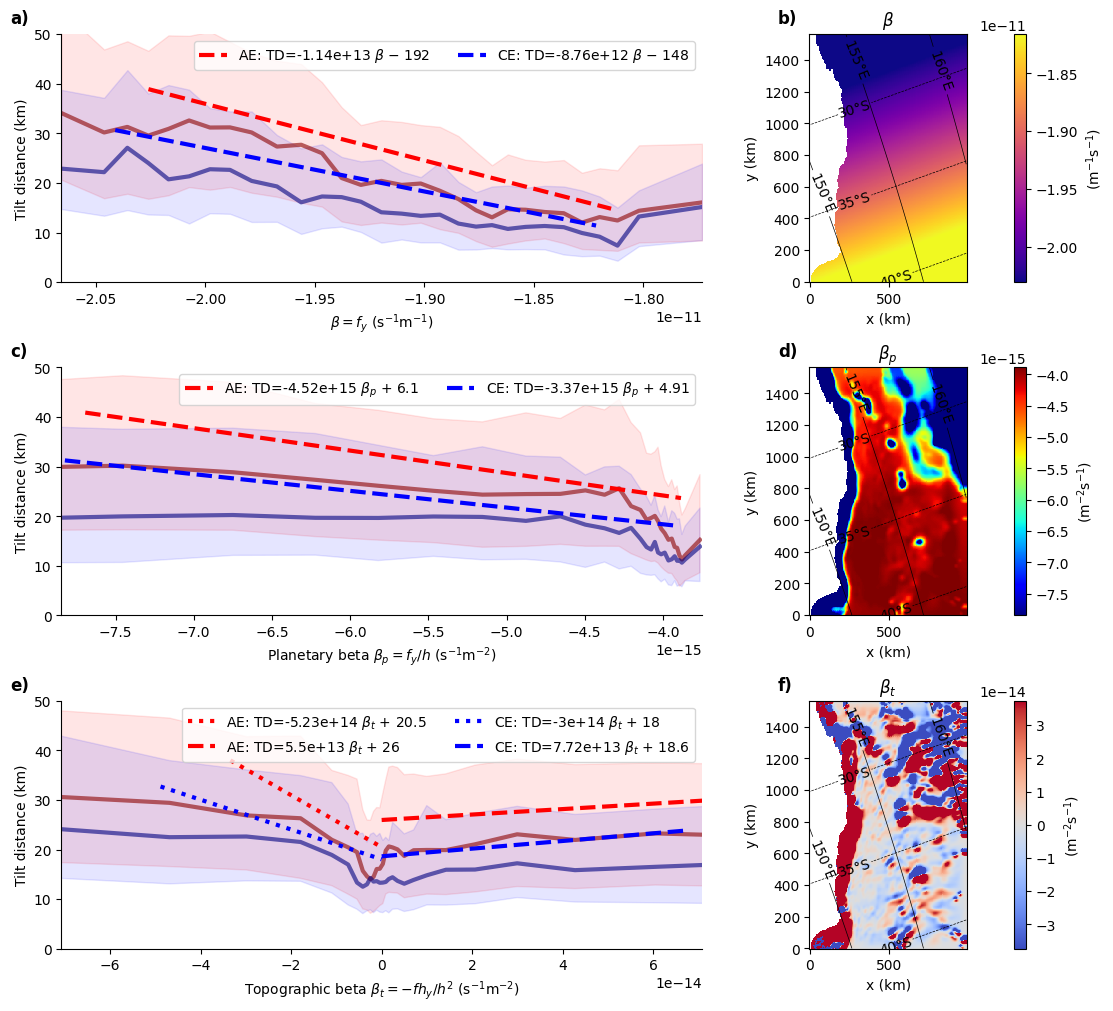

In [6]:
fig = plt.figure(figsize=(11, 10), constrained_layout=True)
gs = fig.add_gridspec(3, 2, width_ratios=[2.5, 1.0], hspace=0, wspace=0)

axs_L = [fig.add_subplot(gs[i, 0]) for i in range(3)]
axs_R = [fig.add_subplot(gs[i, 1]) for i in range(3)]

styles = {
    'AE': {'line': 'darkred', 'fill': 'red'},
    'CE': {'line': 'navy',    'fill': 'blue'}
}

# =========================
# LEFT COLUMN — TD PANELS
# =========================
panel(
    axs_L[0],
    'beta',
    r'$\beta=f_y$ (s$^{-1}$m$^{-1}$)',
    r'$\beta$',
    xlim_flag=True,
    scatter=False
)
axs_L[0].set_ylabel('Tilt distance (km)')

panel(
    axs_L[1],
    'plan_beta',
    r'Planetary beta $\beta_p=f_y/h$ (s$^{-1}$m$^{-2}$)',
    r'$\beta_p$',
    # split=-4.2e-15,
    # reg_hi_override=-3.86e-15,
    xlim=(np.nanpercentile(df_ameda.plan_beta, [10, 90])[0], -3.75e-15)
)
axs_L[1].set_ylabel('Tilt distance (km)')

lo, hi = np.nanpercentile(df_ameda.topo_beta, [10, 90])
cent = max(abs(lo), abs(hi))
panel(
    axs_L[2],
    'topo_beta',
    r'Topographic beta $\beta_t=-fh_y/h^2$ (s$^{-1}$m$^{-2}$)',
    r'$\beta_t$',
    split=0.0,
    xlim=(-cent, cent)
)

axs_L[2].set_ylabel('Tilt distance (km)')

axs_L[0].text(-0.08, 1.1, 'a)', transform=axs_L[0].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs_L[1].text(-0.08, 1.1, 'c)', transform=axs_L[1].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs_L[2].text(-0.08, 1.1, 'e)', transform=axs_L[2].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

for ax in axs_L:
    ax.set_ylim(0, 50)

# =========================
# RIGHT COLUMN — MAPS
# =========================
lo, hi = np.nanpercentile(df_ameda.beta, [10, 90])
pc = axs_R[0].pcolor(X_grid, Y_grid, beta, cmap='plasma', vmin=lo, vmax=hi)
fig.colorbar(pc, ax=axs_R[0], label=r'(m$^{-1}$s$^{-1}$)')
axs_R[0].set_title(r'$\beta$')

lo, hi = np.nanpercentile(df_ameda.plan_beta, [10, 90])
pc = axs_R[1].pcolor(X_grid, Y_grid, plan_beta, cmap='jet', vmin=lo, vmax=hi)
fig.colorbar(pc, ax=axs_R[1], label=r'(m$^{-2}$s$^{-1}$)')
axs_R[1].set_title(r'$\beta_p$')
# axs_R[1].contour(X_grid, Y_grid, plan_beta, levels=[-3.86e-15], colors='w')

lo, hi = np.nanpercentile(df_ameda.topo_beta, [10, 90])
cent = min(abs(lo), abs(hi))
pc = axs_R[2].pcolor(
    X_grid, Y_grid, topo_beta,
    cmap='coolwarm', vmin=-cent, vmax=cent
)
fig.colorbar(pc, ax=axs_R[2], label=r'(m$^{-2}$s$^{-1}$)')
axs_R[2].set_title(r'$\beta_t$')

for ax in axs_R:
    c1 = ax.contour(X_grid, Y_grid, lat_rho, levels=levels_lat,
                    colors='k', linewidths=.5)
    ax.clabel(c1, fmt=lambda v: f"{-v:.0f}°S", inline=True, colors='k')
    c2 = ax.contour(X_grid, Y_grid, lon_rho, levels=levels_lon,
                    colors='k', linewidths=.5)
    ax.clabel(c2, fmt=lambda v: f"{v:.0f}°E", inline=True, colors='k')
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('x (km)'); ax.set_ylabel('y (km)');

axs_R[0].text(-0.2, 1.1, 'b)', transform=axs_R[0].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs_R[1].text(-0.2, 1.1, 'd)', transform=axs_R[1].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs_R[2].text(-0.2, 1.1, 'f)', transform=axs_R[2].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

plt.show()


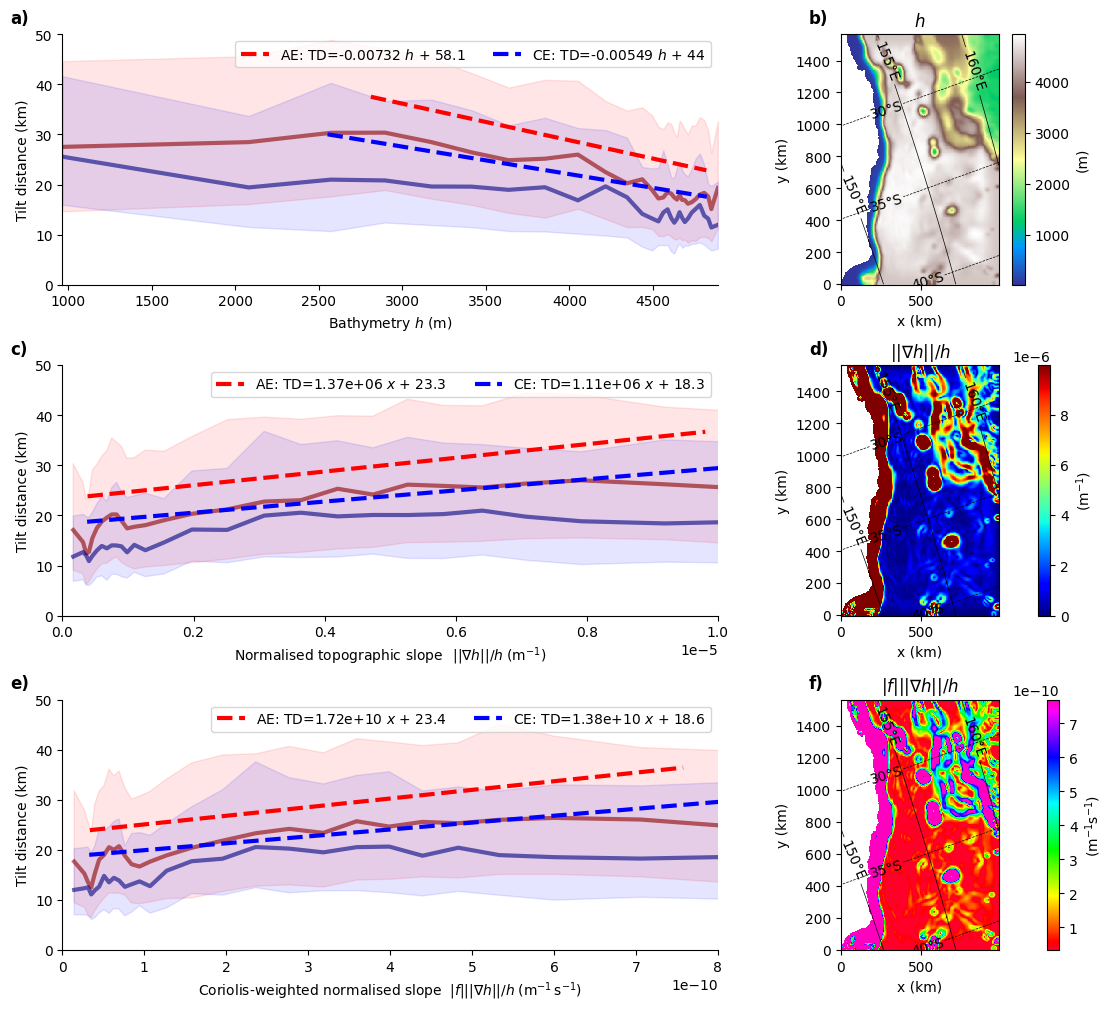

In [7]:
fig = plt.figure(figsize=(11, 10), constrained_layout=True)
gs = fig.add_gridspec(3, 2, width_ratios=[2.5, 1.0], hspace=0.0, wspace=0.0)

axs_L = [fig.add_subplot(gs[i, 0]) for i in range(3)]
axs_R = [fig.add_subplot(gs[i, 1]) for i in range(3)]

styles = {
    'AE': {'line': 'darkred', 'fill': 'red'},
    'CE': {'line': 'navy',    'fill': 'blue'}
}

# =========================
# LEFT COLUMN — TD PANELS
# =========================
lo, hi = np.nanpercentile(df_ameda.h, [10, 90])
hi = df_ameda.h.max()
panel(
    axs_L[0],
    'h',
    r'Bathymetry $h$ (m)',
    '$h$',
    # split=4500,
    # xlim=(lo, hi),
    scatter=False,
    # reg_hi_override=hi
    xlim_flag=True
)

lo, hi = np.nanpercentile(df_ameda.s_norm, [10, 90])
panel(
    axs_L[1],
    's_norm',
    r'Normalised topographic slope $\; \,||\nabla h||/h \; (\mathrm{m^{-1}})$',
    '$x$',
    # split=2e-6,
    xlim=(0, 1e-5),
    scatter=False,
    # reg_lo_override=0
    # xlim_flag=True
)

lo, hi = np.nanpercentile(df_ameda.s_norm_f, [10, 90])
panel(
    axs_L[2],
    's_norm_f',
    r'Coriolis-weighted normalised slope $\; |f|||\nabla h||/h \; (\mathrm{m^{-1}\,s^{-1}})$',
    '$x$',
    # split=1.5e-10,
    xlim=(0, .8e-9),
    scatter=False,
    # reg_lo_override=0,
    # xlim_flag=True
)

for ax in axs_L:
    ax.set_ylabel('Tilt distance (km)')#, fontsize=13)

axs_L[0].text(-0.08, 1.1, 'a)', transform=axs_L[0].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs_L[1].text(-0.08, 1.1, 'c)', transform=axs_L[1].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs_L[2].text(-0.08, 1.1, 'e)', transform=axs_L[2].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

for ax in axs_L:
    ax.set_ylim(0, 50)

# =========================
# RIGHT COLUMN — MAPS
# =========================
pc = axs_R[0].pcolor(X_grid, Y_grid, np.where(mask_rho, h, np.nan), cmap='terrain')
fig.colorbar(pc, ax=axs_R[0], label='(m)')
# axs_R[0].contour(X_grid, Y_grid, h, levels=[4500])
axs_R[0].set_title(r'$h$')

lo, hi = np.nanpercentile(df_ameda.s_norm, [10, 90])
pc = axs_R[1].pcolor(X_grid, Y_grid, s_norm, vmin=0, vmax=hi, cmap='jet')
fig.colorbar(pc, ax=axs_R[1], label=r'(m$^{-1}$)')
axs_R[1].set_title(r'$||\nabla h|| / h$')

lo, hi = np.nanpercentile(df_ameda.s_norm_f, [10, 90])
pc = axs_R[2].pcolor(X_grid, Y_grid, s_norm_f, vmin=lo, vmax=hi, cmap='gist_rainbow')
fig.colorbar(pc, ax=axs_R[2], label=r'(m$^{-1}$s$^{-1}$)')
axs_R[2].set_title(r'$|f| ||\nabla h||/h$')

for ax in axs_R:
    c1 = ax.contour(X_grid, Y_grid, lat_rho, levels=levels_lat, colors='k', linewidths=.5)
    ax.clabel(c1, fmt=lambda v: f"{-v:.0f}°S", inline=True, colors='k')
    c2 = ax.contour(X_grid, Y_grid, lon_rho, levels=levels_lon, colors='k', linewidths=.5)
    ax.clabel(c2, fmt=lambda v: f"{v:.0f}°E", inline=True, colors='k')
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('x (km)'); ax.set_ylabel('y (km)')

axs_R[0].text(-0.2, 1.1, 'b)', transform=axs_R[0].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs_R[1].text(-0.2, 1.1, 'd)', transform=axs_R[1].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs_R[2].text(-0.2, 1.1, 'f)', transform=axs_R[2].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

plt.show()
